In [1]:
import re
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import clone_model
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, TFAutoModel, AutoTokenizer, BertTokenizer
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import requests
from io import BytesIO
import cv2
import matplotlib.pyplot as plt

2025-09-26 11:35:31.973093: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
dataset = tf.data.Dataset.load(
    "dataset",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

dataVal = tf.data.Dataset.load(
    "dataVal",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

2025-09-26 11:35:37.934876: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-26 11:35:37.988088: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-26 11:35:37.988141: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-26 11:35:37.992765: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-26 11:35:37.992813: I external/local_xla/xla/stream_executor

In [3]:
class BertEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, model_name, **kwargs):
        super(BertEmbeddingLayer, self).__init__(**kwargs)
        self.model_name = model_name
        self.embedding_size = None
        self.bert = None

    def build(self, input_shape):
        self.bert = TFAutoModel.from_pretrained(self.model_name)
        self.bert.trainable = True
        self.embedding_size = self.bert.config.hidden_size
        super(BertEmbeddingLayer, self).build(input_shape)

    def call(self, inputs):
        ids, att = inputs
        outputs = self.bert(input_ids=ids, attention_mask=att)
        return outputs.pooler_output

    def get_config(self):
        config = super(BertEmbeddingLayer, self).get_config()
        config.update({
            "model_name": self.model_name
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        clean_config = {k: v for k, v in config.items() 
                      if k in ['model_name', 'name', 'trainable', 'dtype']}
        return cls(**clean_config)

In [4]:
def makemodel(output_bias=None):
    # Text using IndoBertp1
    ids1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="title")
    att1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="titlemask")
    ids2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="content")
    att2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="contentmask")

    indobert1 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert1")
    indobert2 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert2")

    title = indobert1([ids1, att1])
    content = indobert2([ids2, att2])

    # Image using EfficientNetV2s
    img1 = tf.keras.layers.Input(shape=(224,224,3), dtype=tf.uint8, name="image")

    effi = EfficientNetV2B0(
        include_top = False,
        weights = 'imagenet',
        input_shape = (224,224,3),
        pooling = 'max'
    )
    image = effi(img1)

    fin = tf.keras.layers.concatenate([title, content, image])
    fin = tf.keras.layers.BatchNormalization()(fin)
        
    fin = tf.keras.layers.Dense(512, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 

    fin = tf.keras.layers.Dense(256, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(128, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(64, activation='relu')(fin)
    fin = tf.keras.layers.Dropout(0.2)(fin)
    fin = tf.keras.layers.Dense(1, activation='sigmoid')(fin)

    final = tf.keras.Model(inputs=[ids1, att1, ids2, att2, img1], outputs=fin)

    for layer in final.layers:
      layer.trainable = True
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00005)
    final.compile(
        loss = tf.keras.losses.BinaryCrossentropy(),
        optimizer=optimizer,
        metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()]
    )

    return final

final = makemodel()
final.summary()

Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls', 'bert/pooler/dense/bias:0', 'bert/encoder/layer_._4/attention/self/key/kernel:0', 'bert/encoder/layer_._3/attention/output/dense/kernel:0', 'bert/encoder/layer_._11/attention/output/dense/kernel:0', 'bert/encoder/layer_._1/attention/self/query/bias:0', 'bert/encoder/layer_._4/attention/self/query/bias:0', 'bert/encoder/layer_._6/output/dense/bias:0', 'bert/encoder/layer_._7/attention/output/dense/bias:0', 'bert/encoder/layer_._10/output/dense/kernel:0', 'bert/encoder/layer_._2/output/dense/kernel:0', 'bert/encoder/layer_._0/attention/output/dense/kernel:0', 'bert/encoder/layer_._9/intermediate/dense/bias:0', 'bert/encoder/layer_._0/output/LayerNorm/gamma:0', 'bert/encoder/layer_._5/attention/self/value/kernel:0', 'bert/encoder/layer_._11/intermediate/dense/kernel:0', 'bert/encoder/layer_._4/intermediate/dense/kernel:0', 'bert/encoder/layer_._8/

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ titlemask           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content             │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contentmask         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert1           │ (None, 768)       │          0 │ title[0][0],      │
│ (BertEmbeddingLaye… │                   │            │ titlemask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert2           │ (None, 768)       │          0 │ content[0][0],    │
│ (BertEmbeddingLaye… │                   │            │ contentmask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2816)      │          0 │ indobert1[0][0],  │
│ (Concatenate)       │                   │            │ indobert2[0][0],  │
│                     │                   │            │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2816)      │     11,264 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,442,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][

 Total params: 7,549,009 (28.80 MB)

 Trainable params: 7,480,977 (28.54 MB)

 Non-trainable params: 68,032 (265.75 KB)

In [5]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-8
)

history=final.fit(x = dataset,
                  epochs = 50,
                  callbacks=[early_stopping, 
                             # model_checkpoint, 
                             reduce_lr],
                  validation_data=dataVal
                  )

Epoch 1/50


I0000 00:00:1758861410.636245   46837 service.cc:145] XLA service 0x75cb5c0256d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758861410.636359   46837 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-09-26 11:36:52.726976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1758861414.060641   46837 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758861414.274778   46837 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
2025-09-26 11:37:02.503959: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1758861440.946281   47024 asm_compiler.cc:369] ptxas warning :

349/350 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - binary_accuracy: 0.5389 - loss: 0.7564 - precision: 0.4698 - recall: 0.4776

W0000 00:00:1758861528.740295   46833 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758861528.745985   46833 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758861548.312269   47101 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1758861548.498099   47104 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1758861548.587354   47100 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1758861548.725185   47108 asm_compiler.cc:369] ptxas warning : Registers are spilled to loc

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - binary_accuracy: 0.5389 - loss: 0.7563 - precision: 0.4698 - recall: 0.4776

W0000 00:00:1758861590.898530   46839 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758861591.001520   46839 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758861593.592528   47341 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_13839', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1758861606.357387   46833 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1758861606.363328   46833 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1758861608.369451   47443 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_26', 20 bytes spi

350/350 ━━━━━━━━━━━━━━━━━━━━ 254s 389ms/step - binary_accuracy: 0.5390 - loss: 0.7562 - precision: 0.4699 - recall: 0.4776 - val_binary_accuracy: 0.6432 - val_loss: 0.6487 - val_precision: 0.6379 - val_recall: 0.3734 - learning_rate: 5.0000e-05
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - binary_accuracy: 0.6167 - loss: 0.6910 - precision: 0.5675 - recall: 0.4849 - val_binary_accuracy: 0.6865 - val_loss: 0.5961 - val_precision: 0.6639 - val_recall: 0.5332 - learning_rate: 5.0000e-05
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 153ms/step - binary_accuracy: 0.6470 - loss: 0.6404 - precision: 0.6075 - recall: 0.5235 - val_binary_accuracy: 0.7040 - val_loss: 0.5736 - val_precision: 0.6727 - val_recall: 0.5929 - learning_rate: 5.0000e-05
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - binary_accuracy: 0.6707 - loss: 0.6181 - precision: 0.6391 - recall: 0.5518 - val_binary_accuracy: 0.7215 - val_loss: 0.5588 - val_precision: 0.6944 - val_recall: 0.6173 - learning_rate: 5

In [20]:
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def preprocess_text(text, max_length):
    encoded = tokenizer.encode_plus(
    text,
    max_length = max_length,
    padding = 'max_length',
    truncation = True,
    return_tensors='tf'
    )
    return encoded['input_ids'], encoded['attention_mask']

def preprocess_image(img):
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize_with_pad(img, 224, 224)
    img = tf.cast(img,tf.uint8)
    img = tf.expand_dims(img, axis=0)

    plt.figure(figsize=(8, 8))
    plt.imshow(img[0])
    plt.axis('off')
    plt.show()

    return img

def predict_single(model, title_text, content_text, image_input):
    title_ids, title_mask = preprocess_text(title_text, max_length=32)
    content_ids, content_mask = preprocess_text(content_text, max_length=128)

    image = preprocess_image(image_input)

    prediction = model.predict({
        'title': title_ids,
        'titlemask': title_mask,
        'content': content_ids,
        'contentmask': content_mask,
        'image': image
    })
    return prediction[0][0]

def predict_single_detik(model,link,newTitle=None, newContent=None, newImage=None):
    website = requests.get(link)
    html = website.text
    soup = BeautifulSoup(html)
    img = soup.find('meta', {'name':'thumbnailUrl'})['content']
    title = soup.find('h1',{'class':"detail__title"}).get_text(strip=True)
    content = [p.get_text() for p in soup.find_all('p')]
    content = ''.join(s for s in content if s.strip() and '[' not in s and 'SCROLL' not in s and 'Lihat Video' not in s)

    response = requests.get(img)
    image = response.content

    if newTitle is not None:
        title = newTitle

    if newContent is not None:
        content = newContent

    if newImage is not None:
        image = newImage

    print("title: ",title)
    print("content: ",content[:2000])
    
    return predict_single(model,title,content,image)


In [21]:
def demo(link,newTitle=None, newContent=None, newImage=None):
  probability = predict_single_detik(final,link,newTitle, newContent, newImage)
  print(f"Clickbait probability: {probability*100:.2f}%")
  # print(f"Predicted class: {'Clickbait' if probability > 0.5 else 'Not Clickbait'}")

title:  Heboh Kilat di Gunung Guntur dan Papandayan, Ternyata Ini Penyebabnya
content:  Badan Penanggulangan Bencana Daerah (BPBD) Garut, Jawa Barat, menjelaskan asal-usul kilat di dua gunung berapi aktif, yakni Gunung Guntur dan Papandayan. BPBD Garut menyebut hal itu sebagai fenomena alam yang biasa terjadi pada awan kumulonimbus, bukan ancaman erupsi."Tidak benar jika ada informasi bahwa fenomena ini adalah erupsi Gunung Guntur," kata Kepala Pelaksana BPBD Kabupaten Garut Aah Anwar Saefuloh dilansir Antara, Selasa (23/9/2025).Dia mengatakan fenomena petir yang menyala berkali-kali di wilayah Kabupaten Garut pada Senin (22/9) petang merupakan petir dalam awan yang terjadi pada awan kumulonimbus. Fenomena itu, kata dia, terjadi akibat akumulasi dan perbedaan muatan listrik di dalam awan badai.Dia mengatakan kristal es bermuatan positif terbawa ke puncak awan. Sedangkan butiran air dan es yang lebih berat bermuatan negatif berkumpul di bagian bawah awan."Ketidakseimbangan muatan ini me

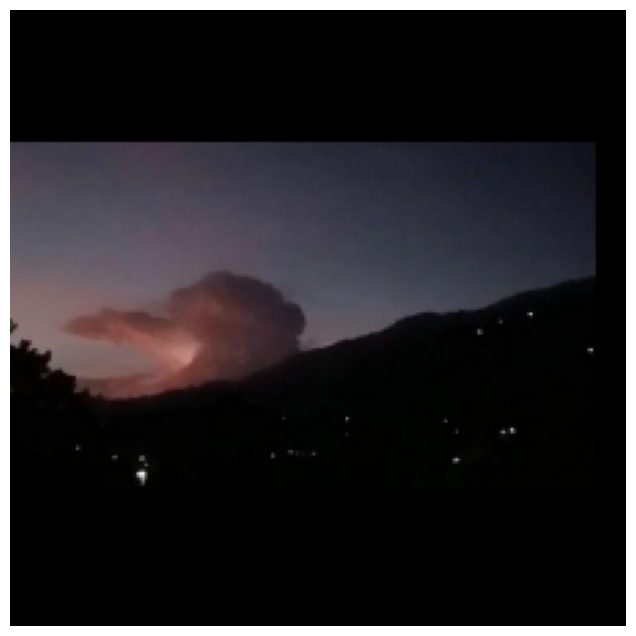

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Clickbait probability: 53.54%


In [31]:
demo('https://news.detik.com/berita/d-8125693/heboh-kilat-di-gunung-guntur-dan-papandayan-ternyata-ini-penyebabnya')

title:  Heboh! Kilat di Gunung Guntur dan Papandayan, Ternyata Ini Penyebabnya
content:  Badan Penanggulangan Bencana Daerah (BPBD) Garut, Jawa Barat, menjelaskan asal-usul kilat di dua gunung berapi aktif, yakni Gunung Guntur dan Papandayan. BPBD Garut menyebut hal itu sebagai fenomena alam yang biasa terjadi pada awan kumulonimbus, bukan ancaman erupsi."Tidak benar jika ada informasi bahwa fenomena ini adalah erupsi Gunung Guntur," kata Kepala Pelaksana BPBD Kabupaten Garut Aah Anwar Saefuloh dilansir Antara, Selasa (23/9/2025).Dia mengatakan fenomena petir yang menyala berkali-kali di wilayah Kabupaten Garut pada Senin (22/9) petang merupakan petir dalam awan yang terjadi pada awan kumulonimbus. Fenomena itu, kata dia, terjadi akibat akumulasi dan perbedaan muatan listrik di dalam awan badai.Dia mengatakan kristal es bermuatan positif terbawa ke puncak awan. Sedangkan butiran air dan es yang lebih berat bermuatan negatif berkumpul di bagian bawah awan."Ketidakseimbangan muatan ini m

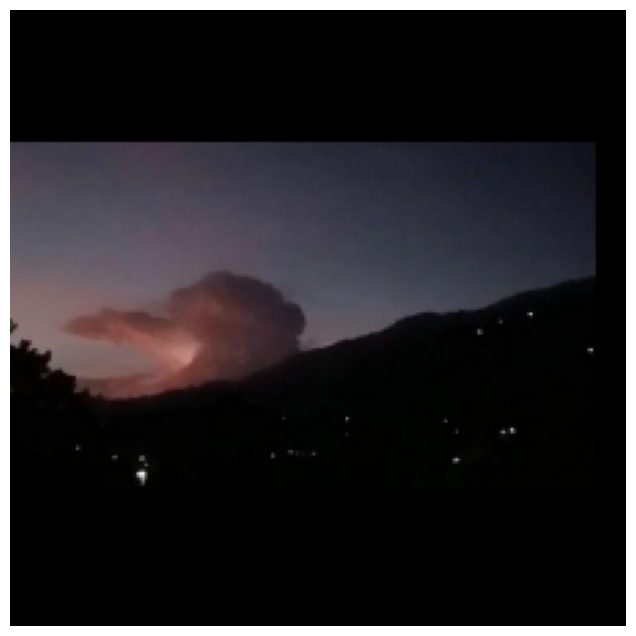

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Clickbait probability: 55.43%


In [32]:
demo('https://news.detik.com/berita/d-8125693/heboh-kilat-di-gunung-guntur-dan-papandayan-ternyata-ini-penyebabnya', 
     newTitle = 'Heboh! Kilat di Gunung Guntur dan Papandayan, Ternyata Ini Penyebabnya')

title:  Prabowo Bicara di PBB Soal Palestina, Usung Solusi Dua Negara
content:  Amerika Serikat - Presiden Prabowo tegaskan dukungan Indonesia atas Solusi Dua Negara di PBB. Indonesia konsisten mendorong perdamaian abadi Palestina-Israel.Presiden Prabowo Subianto menyampaikan pandangannya dalam Konferensi Internasional Tingkat Tinggi (KITT) untuk Penyelesaian Damai atas Masalah Palestina dan Implementasi Solusi Dua Negara di Markas Besar PBB, New York, Amerika Serikat, Senin (22/9/2025). ANTARA FOTO/Fathur RochmanDalam forum itu, Presiden Prabowo menegaskan kembali dukungan Indonesia terhadap Deklarasi New York. Deklarasi tersebut menyebut Solusi Dua Negara sebagai satu-satunya jalan menuju perdamaian abadi bagi Palestina dan Israel. ANTARA FOTO/Fathur RochmanPresiden Prabowo hadir didampingi sejumlah pejabat, di antaranya Menteri Luar Negeri Sugiono, Sekretaris Kabinet Teddy Indra Wijaya, Menteri Investasi dan Hilirisasi Rosan Roeslani, Wakil Tetap RI untuk PBB Umar Hadi, serta Menter

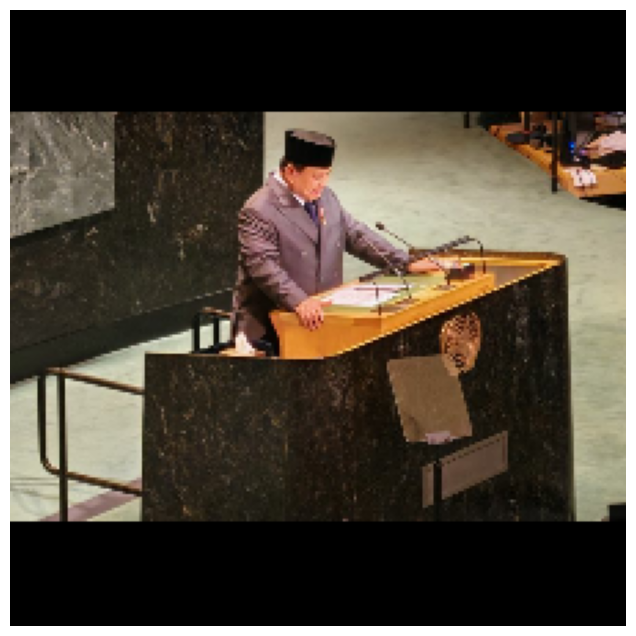

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Clickbait probability: 1.10%


In [33]:
demo('https://news.detik.com/foto-news/d-8125619/prabowo-bicara-di-pbb-soal-palestina-usung-solusi-dua-negara')

title:  Viral! Ternyata Inilah Alasan Prabowo Bicara di PBB Soal Palestina, Usung Solusi Dua Negara
content:  Amerika Serikat - Presiden Prabowo tegaskan dukungan Indonesia atas Solusi Dua Negara di PBB. Indonesia konsisten mendorong perdamaian abadi Palestina-Israel.Presiden Prabowo Subianto menyampaikan pandangannya dalam Konferensi Internasional Tingkat Tinggi (KITT) untuk Penyelesaian Damai atas Masalah Palestina dan Implementasi Solusi Dua Negara di Markas Besar PBB, New York, Amerika Serikat, Senin (22/9/2025). ANTARA FOTO/Fathur RochmanDalam forum itu, Presiden Prabowo menegaskan kembali dukungan Indonesia terhadap Deklarasi New York. Deklarasi tersebut menyebut Solusi Dua Negara sebagai satu-satunya jalan menuju perdamaian abadi bagi Palestina dan Israel. ANTARA FOTO/Fathur RochmanPresiden Prabowo hadir didampingi sejumlah pejabat, di antaranya Menteri Luar Negeri Sugiono, Sekretaris Kabinet Teddy Indra Wijaya, Menteri Investasi dan Hilirisasi Rosan Roeslani, Wakil Tetap RI unt

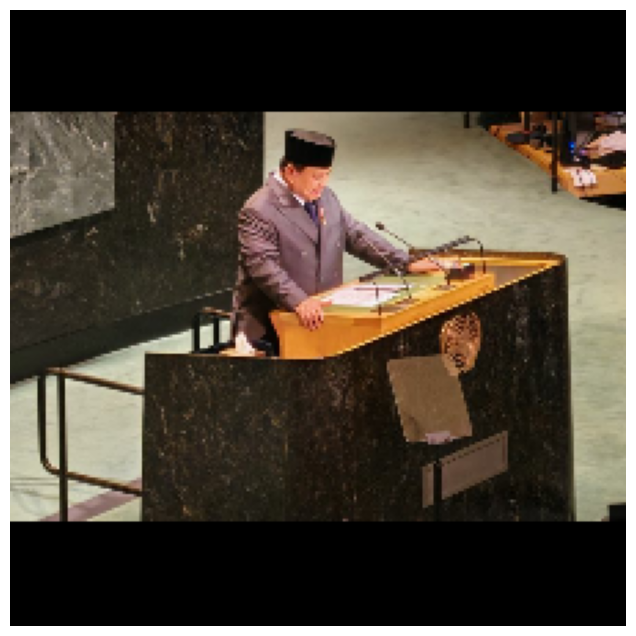

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
Clickbait probability: 3.70%


In [34]:
demo('https://news.detik.com/foto-news/d-8125619/prabowo-bicara-di-pbb-soal-palestina-usung-solusi-dua-negara', 
     newTitle='Viral! Ternyata Inilah Alasan Prabowo Bicara di PBB Soal Palestina, Usung Solusi Dua Negara')

title:  Jadwal Libur Nasional dan Cuti Bersama 2026, Cek Daftarnya!
content:  Tahun 2026 memiliki 25 tanggal merah yang terdiri dari 17 libur nasional dan delapan cuti bersama. Hal ini tercantum dalam Surat Keputusan Bersama (SKB) Menteri Agama, Menteri Ketenagakerjaan, dan Menteri Pendayagunaan Aparatur Negara dan Reformasi Birokrasi Nomor 1497 Tahun 2025 Nomor 1497 Tahun 2025, Nomor 2 Tahun 2025, dan Nomor 5 Tahun 2025 tentang Libur Nasional dan Cuti Bersama 2026.Berikut jadwal libur nasional dan cuti bersama 2026.Cuti bersama adalah hari cuti atau libur khusus yang ditetapkan oleh pemerintah bersamaan dengan hari libur nasional tertentu. Biasanya, cuti bersama jatuh pada sebelum atau sesudah hari libur nasional tertentu.Dalam penerapannya, pelaksanaan cuti bersama bagi perusahaan swasta bersifat fakultatif atau pilihan. Maksudnya, aturan cuti bersama tidak wajib diikuti oleh pegawai maupun perusahaan swasta. Perusahaan yang tidak meliburkan pekerjanya di waktu-waktu cuti bersama pun

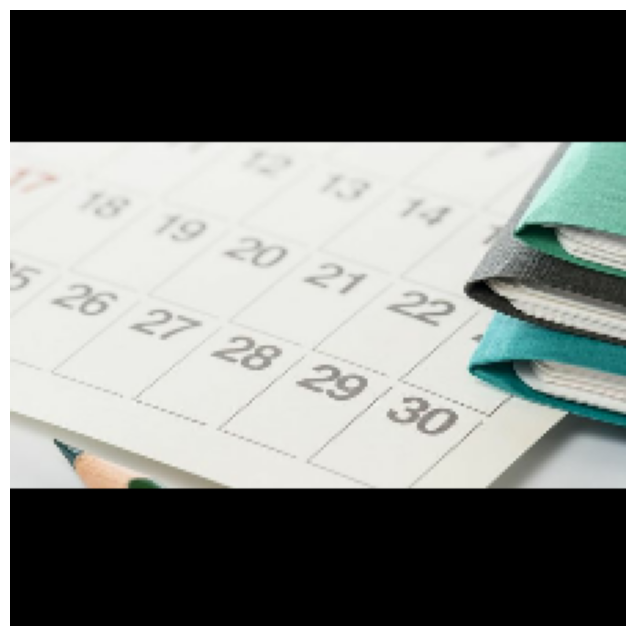

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Clickbait probability: 11.18%


In [35]:
demo('https://news.detik.com/berita/d-8126101/jadwal-libur-nasional-dan-cuti-bersama-2026-cek-daftarnya')

title:  Jadwal Libur Nasional dan Cuti Bersama 2026
content:  Tahun 2026 memiliki 25 tanggal merah yang terdiri dari 17 libur nasional dan delapan cuti bersama. Hal ini tercantum dalam Surat Keputusan Bersama (SKB) Menteri Agama, Menteri Ketenagakerjaan, dan Menteri Pendayagunaan Aparatur Negara dan Reformasi Birokrasi Nomor 1497 Tahun 2025 Nomor 1497 Tahun 2025, Nomor 2 Tahun 2025, dan Nomor 5 Tahun 2025 tentang Libur Nasional dan Cuti Bersama 2026.Berikut jadwal libur nasional dan cuti bersama 2026.Cuti bersama adalah hari cuti atau libur khusus yang ditetapkan oleh pemerintah bersamaan dengan hari libur nasional tertentu. Biasanya, cuti bersama jatuh pada sebelum atau sesudah hari libur nasional tertentu.Dalam penerapannya, pelaksanaan cuti bersama bagi perusahaan swasta bersifat fakultatif atau pilihan. Maksudnya, aturan cuti bersama tidak wajib diikuti oleh pegawai maupun perusahaan swasta. Perusahaan yang tidak meliburkan pekerjanya di waktu-waktu cuti bersama pun tidak dikenai s

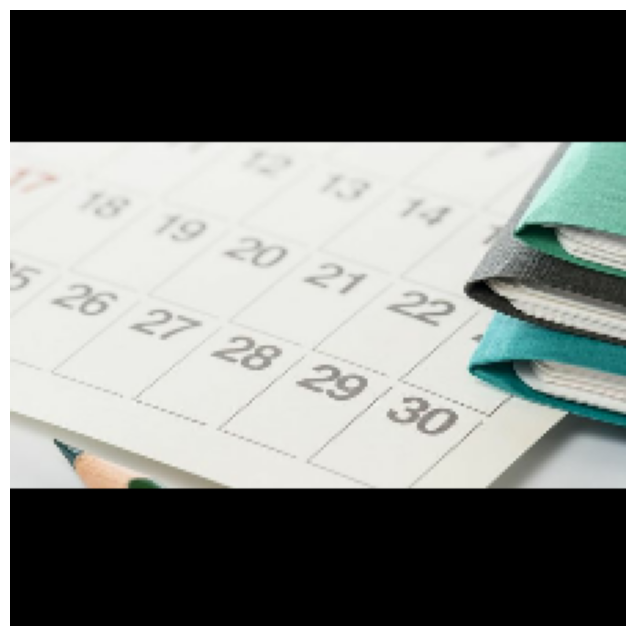

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Clickbait probability: 4.26%


In [36]:
demo('https://news.detik.com/berita/d-8126101/jadwal-libur-nasional-dan-cuti-bersama-2026-cek-daftarnya',
     newTitle='Jadwal Libur Nasional dan Cuti Bersama 2026')

title:  Jadwal Libur Nasional dan Cuti Bersama 2026, Cek Daftarnya!!!!!!!!!!!
content:  Tahun 2026 memiliki 25 tanggal merah yang terdiri dari 17 libur nasional dan delapan cuti bersama. Hal ini tercantum dalam Surat Keputusan Bersama (SKB) Menteri Agama, Menteri Ketenagakerjaan, dan Menteri Pendayagunaan Aparatur Negara dan Reformasi Birokrasi Nomor 1497 Tahun 2025 Nomor 1497 Tahun 2025, Nomor 2 Tahun 2025, dan Nomor 5 Tahun 2025 tentang Libur Nasional dan Cuti Bersama 2026.Berikut jadwal libur nasional dan cuti bersama 2026.Cuti bersama adalah hari cuti atau libur khusus yang ditetapkan oleh pemerintah bersamaan dengan hari libur nasional tertentu. Biasanya, cuti bersama jatuh pada sebelum atau sesudah hari libur nasional tertentu.Dalam penerapannya, pelaksanaan cuti bersama bagi perusahaan swasta bersifat fakultatif atau pilihan. Maksudnya, aturan cuti bersama tidak wajib diikuti oleh pegawai maupun perusahaan swasta. Perusahaan yang tidak meliburkan pekerjanya di waktu-waktu cuti b

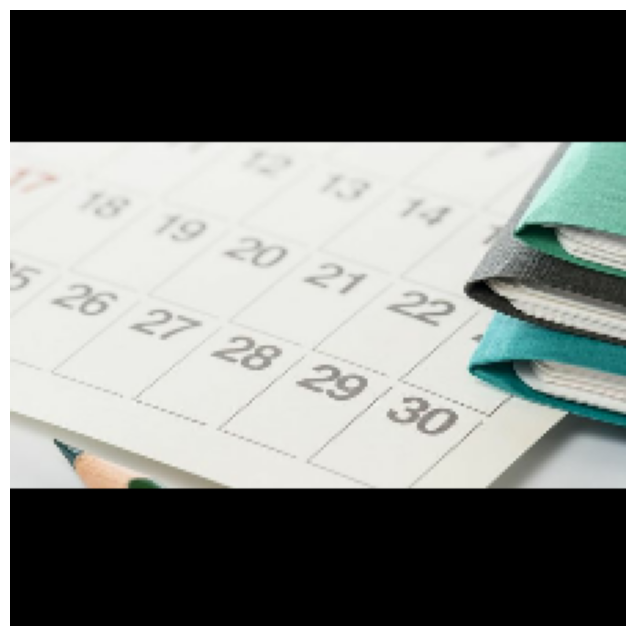

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Clickbait probability: 87.84%


In [38]:
demo('https://news.detik.com/berita/d-8126101/jadwal-libur-nasional-dan-cuti-bersama-2026-cek-daftarnya',
     newTitle='Jadwal Libur Nasional dan Cuti Bersama 2026, Cek Daftarnya!!!!!!!!!!!')